In [1]:
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

In [2]:
def step(grid: np.ndarray) -> np.ndarray:
    """
    Compute one Game of Life step.
    grid: 2D array of 0/1 ints.
    Uses wrap-around (toroidal) edges
    """
    # Count neighbors using rolled shifts
    neighbors = (
        np.roll(np.roll(grid, 1, 0), 1, 1) + # up-left
        np.roll(grid, 1, 0) +                # up
        np.roll(np.roll(grid, 1, 0), -1, 1) + # up-right
        np.roll(grid, 1, 1) +                  # left
        np.roll(grid, -1, 1) +                 # right
        np.roll(np.roll(grid, -1,0), 1, 1) +   # down-left
        np.roll(grid, -1, 0) +                 # down
        np.roll(np.roll(grid, -1, 0), -1, 1)   # down-right
    )

    # Apply rules:
    # - Any live cell with 2 or 3 neighbors survives
    # - Any dead cell with exactly 3 neighbors becomes alive
    survive = (grid == 1) & ((neighbors) | (neighbors == 3))
    born    = (grid == 0) & (neighbors == 3)
    return (survive | born).astype(np.uint8)

In [3]:
#---Patterns-------------------------------------------------------
def place_pattern(grid: np.ndarray, pattern: np.ndarray, top: int, left: int) -> None:
    """Place a small 0/1 pattern into the grid at (top,left),"""
    h, w = pattern.shape
    grid[top:top+h, left:left+w] = pattern

GLIDER = np.array([
    [0,1,0],
    [0,0,1],
    [1,1,1],
], dtype=np.uint8)

BLINKER = np.array([
    [1,1,1]
], dtype=np.uint8)

In [4]:
#---Simulation setup-----------------------------------------------

H,W = 80, 120
grid = np.zeros((H, W), dtype=np.uint8)

# Seed with a few patterns
place_pattern(grid, GLIDER, 10, 10)
place_pattern(grid, GLIDER, 30, 20)
place_pattern(grid, BLINKER, 50, 60)

# or random seed (uncomment to try)
# rng = random.default_rng(0)
# grid = (rng.random((H, W)) < o.10).astype(np.uint8)

# ---Animation-----------------------------------------------------

from IPython.display import display, HTML

fig, ax = plt.subplots(figsize=(7, 5))
img = ax.imshow(grid, interpolation="nearest", vmin=0, vmax=1)
ax.set_title("First Game of Life Test Model")
ax.set_axis_off()

def update(_):
    global grid
    grid = step(grid)
    img.set_data(grid)
    return (img,)

anim = animation.FuncAnimation(fig, update, frames=200, interval=50, blit=False)

plt.close(fig)  # prevents a static duplicate figure in the output
display(HTML(anim.to_jshtml()))
            

In [5]:
import numpy as np

def run_life(
    grid: np.ndarray,
    steps: int,
    *,
    wrap: bool = True,
    record_every: int = 1
):
    """
    Run Game of Life for 'steps'.
    Returns: grids (optional snapshots) asnd metrics dict.
    """
    grid = grid.copy().astype(np.uint8)

    live = []
    births = []
    deaths = []
    snapshots = []

    def neighbor_count_wrap(g):
        return (
            np.roll(np.roll(g, 1, 0), 1, 1) +
            np.roll(g, 1, 0) +
            np.roll(np.roll(g, 1, 0), -1, 1) +
            np.roll(g, 1, 1) +
            np.roll(g, -1, 1) +
            np.roll(np.roll(g, -1, 0), 1, 1) +
            np.roll(g, -1, 0) +
            np.roll(np.roll(g, -1, 0), -1, 1)
        )
    def neighbor_count_nowrap(g):
        # pad with zeros so edges don't wrap
        p = np.pad(g, 1, mode="constant")
        # sum 8 neighbors via slicing (fast + clean)
        return (
            p[0:-2, 0:-2] + p[0:-2, 1:-1] + p[0:-2, 2:] +
            p[1:-1, 0:-2]                 + p[1:-1, 2:] +
            p[2:  , 0:-2] + p[2:  , 1:-1] + p[2:  , 2:]
        )
    neighbor_count = neighbor_count_wrap if wrap else neighbor_count_nowrap

    for t in range(steps):
        n = neighbor_count(grid)

        survive = (grid == 1) & ((n == 2) | (n == 3))
        born =(grid == 0) & (n == 3)
        next_grid = (survive | born).astype(np.uint8)

        #metrics
        live.append(int(next_grid.sum()))
        births.append(int(born.sum()))
        deaths.append(int(((grid == 1) & (next_grid == 0)).sum()))

        grid = next_grid

        if (t % record_every) == 0:
            snapshots.append(grid.copy())

    metrics = {
        "live": np.array(live),
        "births": np.array(births),
        "deaths": np.array(deaths),
    }
    return np.array(snapshots), metrics


In [6]:

# Random initial condition

rng = np.random.default_rng(0)
H, W = 80, 120
init = (rng.random((H, W)) < 0.18).astype(np.uint8)

snaps, metrics = run_life(init, steps=300, wrap=False, record_every=10)

metrics["live"][:10], metrics["births"][:10], metrics["deaths"][:10]

(array([1611, 1394, 1352, 1256, 1217, 1243, 1191, 1195, 1192, 1150]),
 array([942, 637, 581, 529, 539, 521, 474, 490, 466, 449]),
 array([1097,  854,  623,  625,  578,  495,  526,  486,  469,  491]))

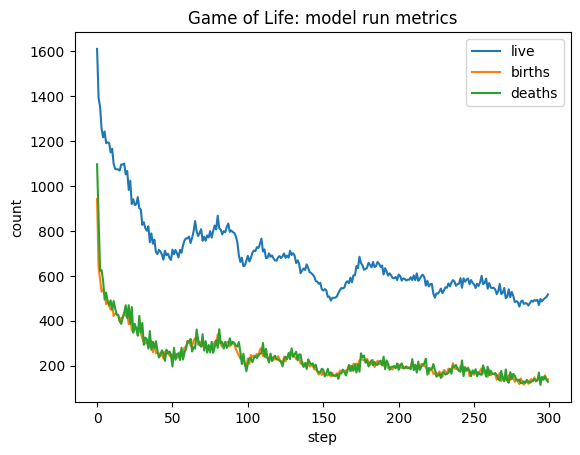

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(metrics["live"], label="live")
plt.plot(metrics["births"], label="births")
plt.plot(metrics["deaths"], label="deaths")
plt.legend()
plt.xlabel("step")
plt.ylabel("count")
plt.title("Game of Life: model run metrics")
plt.show()

In [8]:
g2 = step(grid)
print("changed cells:", np.sum(g2 != grid))

changed cells: 0


In [9]:
import numpy as np

H, W = 50, 80
grid = np.zeros((H, W), dtype=np.uint8)

# A glider (will move)
glider = np.array([
    [0,1,0],
    [0,0,1],
    [1,1,1]
], dtype=np.uint8)

grid[1:4, 1:4] = glider

g2 = step(grid)
print("changed cells:", np.sum(g2 != grid))

changed cells: 3
